# NB13 — Graph Navigation Policy Laboratory

**A common, auditable interface for nine ways of walking through the same knowledge graph**

Navigation-Conditioned Knowledge Evolution laboratory  
Author: Alejandro Reynoso  
Version 1.0 · Deterministic research edition

This notebook is designed for Google Colab and local Jupyter. It runs without an API key.
Every result is derived from a fixed synthetic governed vault, a fixed query battery, fixed
budgets, and seeded algorithms. The deterministic answer interpreter makes the effect of
navigation observable without confounding it with stochastic model variation.

## Reproducibility and scientific controls

The experiment holds constant the stored graph, questions, answer interpreter, budget,
random seed, and governance criteria. The variable of interest is the navigation policy.
Outputs are written to `NCKE_Lab`, together with a manifest and hashes.

In [2]:
from pathlib import Path
import importlib.util, subprocess, sys

required = {
    "networkx": "networkx",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}
missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

IN_COLAB = Path("/content").exists()
LAB_ROOT = Path("/content/NCKE_Lab") if IN_COLAB else Path.cwd() / "NCKE_Lab"
LAB_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Laboratory root: {LAB_ROOT}")

Laboratory root: /content/NCKE_Lab


In [3]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import random
import statistics
import zipfile
from collections import Counter, defaultdict, deque
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RNG = random.Random(314159)
np.random.seed(314159)

POLICIES = [
    "semantic", "local", "diffusion", "community", "typed_path",
    "goal_directed", "contrastive", "exploratory", "hybrid",
]

EDGE_TYPES = {
    "supports", "contradicts", "exposed_to", "mitigates", "depends_on",
    "competes_with", "causes", "informed", "resulted_in", "concerns",
    "derived_from", "crosses", "updates",
}

def stable_hash(value: Any) -> str:
    raw = json.dumps(value, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def add_node(g: nx.MultiDiGraph, node_id: str, kind: str, text: str, **attrs: Any) -> None:
    attrs.setdefault("status", "authoritative")
    attrs.setdefault("source", "synthetic_governed_vault")
    attrs.setdefault("reliability", 0.80)
    attrs.setdefault("polarity", 0.0)
    g.add_node(node_id, kind=kind, text=text, **attrs)

def link(g: nx.MultiDiGraph, u: str, v: str, rel: str, weight: float = 1.0, **attrs: Any) -> None:
    if rel not in EDGE_TYPES:
        raise ValueError(f"Unknown relationship type: {rel}")
    g.add_edge(u, v, rel=rel, weight=float(weight), **attrs)

def build_baseline_graph() -> nx.MultiDiGraph:
    """A compact governed investment-bank vault with claims, decisions and outcomes."""
    g = nx.MultiDiGraph(graph_version="G0", title="Navigation-conditioned knowledge laboratory")

    entities = {
        "AlphaBank": ("company", "AlphaBank: diversified bank with a large floating-rate loan book and strong deposit franchise."),
        "BetaPayments": ("company", "BetaPayments: high-growth payments platform with cloud-native infrastructure and thin current margins."),
        "GammaRetail": ("company", "GammaRetail: consumer retailer exposed to discretionary demand, imported inventory and peso depreciation."),
        "DeltaLogistics": ("company", "DeltaLogistics: logistics operator with pricing power, fuel exposure and regional network effects."),
        "EpsilonEnergy": ("company", "EpsilonEnergy: regulated renewable-energy producer with long-duration debt and contracted revenues."),
        "ZetaCloud": ("company", "ZetaCloud: enterprise cloud provider with recurring revenues and material cyber-security obligations."),
        "EtaInsure": ("company", "EtaInsure: insurer whose investment income benefits from rates but whose claims rise with inflation."),
        "ThetaBuild": ("company", "ThetaBuild: construction company exposed to rates, infrastructure spending and material costs."),
        "Rate_Hike": ("factor", "Rate hike: policy rates rise sharply, lifting funding costs and discount rates."),
        "Inflation": ("factor", "Inflation: persistent price pressure raises nominal revenues, costs, claims and policy uncertainty."),
        "FX_Depreciation": ("factor", "FX depreciation: the peso weakens, increasing imported-input and foreign-debt costs."),
        "Regulation_Tightening": ("factor", "Regulation tightening: higher capital, data and conduct requirements constrain execution."),
        "Cyber_Shock": ("factor", "Cyber shock: material operational disruption and customer-trust event."),
        "Consumer_Slowdown": ("factor", "Consumer slowdown: real disposable income and discretionary demand weaken."),
        "Acquire_Beta": ("decision", "Decision: AlphaBank considers acquiring BetaPayments to accelerate digital distribution."),
        "Expand_Credit": ("decision", "Decision: AlphaBank considers expanding unsecured consumer credit."),
        "Hedge_FX": ("decision", "Decision: GammaRetail considers increasing its foreign-exchange hedge ratio."),
        "Invest_Cloud": ("decision", "Decision: the group considers migrating critical workloads to ZetaCloud."),
        "Delay_Capex": ("decision", "Decision: ThetaBuild considers delaying rate-sensitive capital expenditure."),
    }
    for node_id, (kind, text) in entities.items():
        add_node(g, node_id, kind, text)

    claims = [
        ("E001", "evidence", "BetaPayments increases AlphaBank cross-selling and lowers customer acquisition cost.", 0.82, 1.0),
        ("E002", "evidence", "BetaPayments valuation assumes aggressive growth and is highly sensitive to discount rates.", 0.88, -1.0),
        ("E003", "evidence", "Integration of legacy bank controls with cloud-native payments creates execution risk.", 0.91, -1.0),
        ("E004", "evidence", "Prior digital integrations improved retention when product teams remained autonomous.", 0.76, 1.0),
        ("E005", "evidence", "A sharp rate hike compresses AlphaBank margins when deposit repricing accelerates.", 0.84, -1.0),
        ("E006", "evidence", "AlphaBank's floating-rate assets initially benefit from higher policy rates.", 0.86, 1.0),
        ("E007", "evidence", "Unsecured credit losses rise nonlinearly during consumer slowdowns.", 0.94, -1.0),
        ("E008", "evidence", "GammaRetail passes through only part of imported inflation to customers.", 0.89, -1.0),
        ("E009", "evidence", "Layered FX hedges stabilize gross margin but impose liquidity requirements.", 0.87, 1.0),
        ("E010", "evidence", "Over-hedging can destroy value if currency weakness reverses.", 0.82, -1.0),
        ("E011", "evidence", "ZetaCloud migration reduces unit costs and improves analytic flexibility.", 0.81, 1.0),
        ("E012", "evidence", "Concentrating critical workloads in one provider raises operational concentration risk.", 0.93, -1.0),
        ("E013", "evidence", "Multi-cloud architecture reduces concentration but increases coordination cost.", 0.79, 1.0),
        ("E014", "evidence", "EpsilonEnergy's contracted revenues provide partial inflation protection.", 0.90, 1.0),
        ("E015", "evidence", "Long-duration project debt loses flexibility under a sustained rate shock.", 0.91, -1.0),
        ("E016", "evidence", "EtaInsure earns more investment income as reinvestment yields increase.", 0.88, 1.0),
        ("E017", "evidence", "Claims severity rises faster than premiums during unexpected inflation.", 0.92, -1.0),
        ("E018", "evidence", "DeltaLogistics network density creates pricing power during mild disruption.", 0.80, 1.0),
        ("E019", "evidence", "Fuel-price shocks erode margins before contractual surcharges reset.", 0.86, -1.0),
        ("E020", "evidence", "Delaying capex preserves liquidity but can sacrifice scarce infrastructure concessions.", 0.85, -1.0),
        ("E021", "evidence", "Staged capex with explicit option gates dominates an irreversible cancellation.", 0.90, 1.0),
        ("E022", "evidence", "New data regulation increases the fixed cost of payments integration.", 0.89, -1.0),
        ("E023", "evidence", "A combined bank-payments data estate improves fraud detection.", 0.83, 1.0),
        ("E024", "evidence", "Independent model validation is required before automated credit expansion.", 0.96, -1.0),
    ]
    for node_id, kind, text, reliability, polarity in claims:
        add_node(g, node_id, kind, text, reliability=reliability, polarity=polarity,
                 status="authoritative", source=f"document_{1 + int(node_id[1:]) % 7:02d}")

    outcomes = {
        "O_Digital_Autonomy": "Outcome: integrations preserving product autonomy achieved faster customer migration.",
        "O_Credit_Loss": "Outcome: a prior consumer slowdown produced losses above the linear stress assumption.",
        "O_Hedge_Liquidity": "Outcome: the FX hedge protected margin but generated a temporary collateral call.",
        "O_Cloud_Resilience": "Outcome: workload segmentation contained a prior service disruption.",
        "O_Option_Value": "Outcome: staged investment preserved concession rights and reduced downside exposure.",
    }
    for node_id, text in outcomes.items():
        add_node(g, node_id, "outcome", text, reliability=0.95)

    # Core exposure and decision structure.
    links = [
        ("AlphaBank", "Rate_Hike", "exposed_to", 0.9), ("AlphaBank", "Consumer_Slowdown", "exposed_to", 0.8),
        ("BetaPayments", "Rate_Hike", "exposed_to", 0.8), ("BetaPayments", "Regulation_Tightening", "exposed_to", 0.9),
        ("GammaRetail", "FX_Depreciation", "exposed_to", 1.0), ("GammaRetail", "Consumer_Slowdown", "exposed_to", 0.9),
        ("DeltaLogistics", "Inflation", "exposed_to", 0.7), ("EpsilonEnergy", "Rate_Hike", "exposed_to", 0.9),
        ("ZetaCloud", "Cyber_Shock", "exposed_to", 1.0), ("EtaInsure", "Inflation", "exposed_to", 0.9),
        ("ThetaBuild", "Rate_Hike", "exposed_to", 0.9), ("ThetaBuild", "Inflation", "exposed_to", 0.7),
        ("Acquire_Beta", "AlphaBank", "concerns", 1.0), ("Acquire_Beta", "BetaPayments", "concerns", 1.0),
        ("Expand_Credit", "AlphaBank", "concerns", 1.0), ("Hedge_FX", "GammaRetail", "concerns", 1.0),
        ("Invest_Cloud", "ZetaCloud", "concerns", 1.0), ("Delay_Capex", "ThetaBuild", "concerns", 1.0),
        ("E001", "Acquire_Beta", "supports", 1.0), ("E002", "Acquire_Beta", "contradicts", 1.0),
        ("E003", "Acquire_Beta", "contradicts", 1.0), ("E004", "Acquire_Beta", "supports", 0.8),
        ("E022", "Acquire_Beta", "contradicts", 0.9), ("E023", "Acquire_Beta", "supports", 0.9),
        ("E005", "Expand_Credit", "contradicts", 0.8), ("E006", "Expand_Credit", "supports", 0.7),
        ("E007", "Expand_Credit", "contradicts", 1.0), ("E024", "Expand_Credit", "contradicts", 1.0),
        ("E008", "Hedge_FX", "supports", 0.9), ("E009", "Hedge_FX", "supports", 1.0),
        ("E010", "Hedge_FX", "contradicts", 0.8), ("E011", "Invest_Cloud", "supports", 0.9),
        ("E012", "Invest_Cloud", "contradicts", 1.0), ("E013", "Invest_Cloud", "supports", 0.8),
        ("E014", "EpsilonEnergy", "supports", 0.8), ("E015", "EpsilonEnergy", "contradicts", 1.0),
        ("E016", "EtaInsure", "supports", 0.9), ("E017", "EtaInsure", "contradicts", 1.0),
        ("E018", "DeltaLogistics", "supports", 0.8), ("E019", "DeltaLogistics", "contradicts", 0.9),
        ("E020", "Delay_Capex", "contradicts", 0.9), ("E021", "Delay_Capex", "supports", 1.0),
        ("E004", "O_Digital_Autonomy", "resulted_in", 0.8), ("E007", "O_Credit_Loss", "resulted_in", 1.0),
        ("E009", "O_Hedge_Liquidity", "resulted_in", 0.9), ("E013", "O_Cloud_Resilience", "resulted_in", 0.8),
        ("E021", "O_Option_Value", "resulted_in", 0.9),
        ("Rate_Hike", "Consumer_Slowdown", "causes", 0.7), ("Inflation", "Rate_Hike", "causes", 0.8),
        ("FX_Depreciation", "Inflation", "causes", 0.7), ("Cyber_Shock", "Regulation_Tightening", "causes", 0.6),
        ("AlphaBank", "BetaPayments", "depends_on", 0.6), ("GammaRetail", "DeltaLogistics", "depends_on", 0.7),
        ("BetaPayments", "ZetaCloud", "depends_on", 0.8), ("AlphaBank", "EtaInsure", "competes_with", 0.4),
    ]
    for u, v, rel, weight in links:
        link(g, u, v, rel, weight)
    return g

QUERIES = [
    {
        "query_id": "Q01", "text": "Should AlphaBank acquire BetaPayments under higher rates and tighter regulation?",
        "target": "Acquire_Beta", "keywords": ["AlphaBank", "BetaPayments", "Rate_Hike", "Regulation_Tightening"],
        "expected": "caution", "risk_tier": "high", "task_class": "strategic_decision",
    },
    {
        "query_id": "Q02", "text": "Should AlphaBank expand unsecured consumer credit during a consumer slowdown?",
        "target": "Expand_Credit", "keywords": ["AlphaBank", "Consumer_Slowdown", "Rate_Hike"],
        "expected": "caution", "risk_tier": "high", "task_class": "risk_decision",
    },
    {
        "query_id": "Q03", "text": "How should GammaRetail manage foreign-exchange depreciation risk?",
        "target": "Hedge_FX", "keywords": ["GammaRetail", "FX_Depreciation", "Inflation"],
        "expected": "proceed", "risk_tier": "medium", "task_class": "risk_decision",
    },
    {
        "query_id": "Q04", "text": "Should critical workloads migrate to ZetaCloud?",
        "target": "Invest_Cloud", "keywords": ["ZetaCloud", "Cyber_Shock", "Regulation_Tightening"],
        "expected": "qualified", "risk_tier": "high", "task_class": "technology_decision",
    },
    {
        "query_id": "Q05", "text": "Should ThetaBuild delay capital expenditure after a rate shock?",
        "target": "Delay_Capex", "keywords": ["ThetaBuild", "Rate_Hike", "Inflation"],
        "expected": "qualified", "risk_tier": "medium", "task_class": "capital_allocation",
    },
    {
        "query_id": "Q06", "text": "Which business is most resilient to combined inflation and higher rates?",
        "target": "EpsilonEnergy", "keywords": ["Inflation", "Rate_Hike", "EpsilonEnergy", "EtaInsure"],
        "expected": "qualified", "risk_tier": "medium", "task_class": "comparative_analysis",
    },
]

def node_documents(g: nx.MultiDiGraph) -> tuple[list[str], list[str]]:
    ids = list(g.nodes())
    docs = [f"{n} {g.nodes[n].get('kind','')} {g.nodes[n].get('text','')}" for n in ids]
    return ids, docs

def semantic_scores(g: nx.MultiDiGraph, query: str) -> dict[str, float]:
    ids, docs = node_documents(g)
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    x = vectorizer.fit_transform(docs + [query])
    sims = cosine_similarity(x[-1], x[:-1]).ravel()
    return {node_id: float(score) for node_id, score in zip(ids, sims)}

def undirected_simple(g: nx.MultiDiGraph) -> nx.Graph:
    h = nx.Graph()
    h.add_nodes_from(g.nodes())
    for u, v, data in g.edges(data=True):
        w = float(data.get("weight", 1.0))
        if h.has_edge(u, v):
            h[u][v]["weight"] += w
        else:
            h.add_edge(u, v, weight=w)
    return h

def ppr(g: nx.MultiDiGraph, personalization: dict[str, float], alpha: float = 0.85,
        iterations: int = 80) -> dict[str, float]:
    h = undirected_simple(g)
    nodes = list(h.nodes())
    p = np.array([max(personalization.get(n, 0.0), 0.0) for n in nodes], dtype=float)
    if p.sum() == 0:
        p[:] = 1.0
    p /= p.sum()
    rank = p.copy()
    index = {n: i for i, n in enumerate(nodes)}
    for _ in range(iterations):
        nxt = (1.0 - alpha) * p
        for u in nodes:
            i = index[u]
            nbrs = list(h.neighbors(u))
            if not nbrs:
                nxt += alpha * rank[i] * p
                continue
            weights = np.array([h[u][v].get("weight", 1.0) for v in nbrs], dtype=float)
            total_weight = weights.sum()
            if total_weight <= 0 or not np.isfinite(total_weight):
                weights = np.full(len(nbrs), 1.0 / len(nbrs))
            else:
                weights /= total_weight
            for v, w in zip(nbrs, weights):
                nxt[index[v]] += alpha * rank[i] * w
        if np.abs(nxt - rank).sum() < 1e-10:
            rank = nxt
            break
        rank = nxt
    return {n: float(rank[index[n]]) for n in nodes}

def seed_nodes(g: nx.MultiDiGraph, query: dict[str, Any], scores: dict[str, float], n: int = 3) -> list[str]:
    explicit = [x for x in query.get("keywords", []) if x in g]
    ranked = sorted(scores, key=scores.get, reverse=True)
    return list(dict.fromkeys(explicit + ranked))[:n]

def induced_trace_edges(g: nx.MultiDiGraph, visited: Iterable[str]) -> list[dict[str, Any]]:
    keep = set(visited)
    rows = []
    for u, v, key, data in g.edges(keys=True, data=True):
        if u in keep and v in keep:
            rows.append({"u": u, "v": v, "key": key, "rel": data.get("rel"), "weight": data.get("weight", 1.0)})
    return rows

def navigate(g: nx.MultiDiGraph, query: dict[str, Any], policy: str, budget: int = 10,
             max_depth: int = 4) -> dict[str, Any]:
    if policy not in POLICIES:
        raise ValueError(f"Unknown policy: {policy}")
    scores = semantic_scores(g, query["text"])
    seeds = seed_nodes(g, query, scores)
    h = undirected_simple(g)
    visited: list[str] = []
    retained: list[str] = []
    policy_score: dict[str, float] = {}

    if policy == "semantic":
        retained = sorted(scores, key=scores.get, reverse=True)[:budget]
        visited = retained.copy()
        policy_score = scores

    elif policy == "local":
        queue = deque((s, 0) for s in seeds)
        seen = set()
        while queue and len(visited) < max(budget * 3, budget):
            node, depth = queue.popleft()
            if node in seen or depth > max_depth:
                continue
            seen.add(node); visited.append(node)
            nbrs = sorted(h.neighbors(node), key=lambda n: scores.get(n, 0.0), reverse=True)
            queue.extend((n, depth + 1) for n in nbrs)
        policy_score = {n: scores.get(n, 0.0) + 1 / (1 + min(
            [nx.shortest_path_length(h, s, n) for s in seeds if nx.has_path(h, s, n)] or [99]
        )) for n in visited}
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "diffusion":
        personal = {n: scores[n] for n in scores if scores[n] > 0}
        for s in seeds:
            personal[s] = personal.get(s, 0.0) + 1.0
        policy_score = ppr(g, personal)
        retained = sorted(policy_score, key=policy_score.get, reverse=True)[:budget]
        visited = retained.copy()

    elif policy == "community":
        communities = list(nx.community.greedy_modularity_communities(h, weight="weight"))
        community_scores = []
        for i, community in enumerate(communities):
            val = sum(scores.get(n, 0.0) for n in community) + 0.5 * sum(n in seeds for n in community)
            community_scores.append((val, i, community))
        community_scores.sort(reverse=True, key=lambda x: x[0])
        for _, _, community in community_scores:
            ranked = sorted(community, key=lambda n: scores.get(n, 0.0), reverse=True)
            visited.extend(ranked)
            if len(set(visited)) >= budget * 2:
                break
        visited = list(dict.fromkeys(visited))
        policy_score = {n: scores.get(n, 0.0) + 0.15 / (1 + h.degree(n)) for n in visited}
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "typed_path":
        allowed = {"supports", "contradicts", "concerns", "exposed_to", "causes", "resulted_in", "mitigates"}
        frontier = deque((s, 0) for s in seeds)
        seen = set()
        while frontier and len(visited) < budget * 4:
            node, depth = frontier.popleft()
            if node in seen or depth > max_depth:
                continue
            seen.add(node); visited.append(node)
            candidates = []
            for u, v, data in itertools.chain(g.out_edges(node, data=True), g.in_edges(node, data=True)):
                if data.get("rel") in allowed:
                    nxt = v if u == node else u
                    candidates.append(nxt)
            for nxt in sorted(set(candidates), key=lambda n: scores.get(n, 0.0), reverse=True):
                frontier.append((nxt, depth + 1))
        policy_score = {
            n: scores.get(n, 0.0) + 0.25 * (g.nodes[n].get("kind") in {"evidence", "outcome"})
            for n in visited
        }
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    elif policy == "goal_directed":
        beam = [([s], scores.get(s, 0.0) + 0.2) for s in seeds]
        completed = []
        seen_paths = set()
        for _ in range(max_depth):
            candidates = []
            for path, value in beam:
                node = path[-1]
                for nbr in h.neighbors(node):
                    if nbr in path:
                        continue
                    rel_bonus = 0.0
                    for data in g.get_edge_data(node, nbr, default={}).values():
                        rel_bonus = max(rel_bonus, 0.25 if data.get("rel") in {"supports", "contradicts", "causes"} else 0.05)
                    new_path = path + [nbr]
                    new_value = value + scores.get(nbr, 0.0) + rel_bonus + 0.04 / (1 + h.degree(nbr))
                    key = tuple(new_path)
                    if key not in seen_paths:
                        seen_paths.add(key); candidates.append((new_path, new_value))
            candidates.sort(key=lambda x: x[1], reverse=True)
            beam = candidates[: max(4, budget // 2)]
            completed.extend(beam)
        completed.sort(key=lambda x: x[1], reverse=True)
        for path, value in completed:
            for node in path:
                if node not in visited:
                    visited.append(node)
                    policy_score[node] = max(policy_score.get(node, -1e9), value / len(path))
        retained = sorted(visited, key=lambda n: policy_score.get(n, 0.0), reverse=True)[:budget]

    elif policy == "contrastive":
        ranked = sorted(scores, key=scores.get, reverse=True)
        relevant = ranked[: max(budget * 3, 20)]
        positive = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) > 0]
        negative = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) < 0]
        neutral = [n for n in relevant if float(g.nodes[n].get("polarity", 0.0)) == 0]
        retained = []
        while len(retained) < budget and (positive or negative or neutral):
            for bucket in (positive, negative, neutral):
                if bucket and len(retained) < budget:
                    retained.append(bucket.pop(0))
        visited = relevant
        policy_score = {
            n: scores.get(n, 0.0) + 0.20 * abs(float(g.nodes[n].get("polarity", 0.0)))
            for n in visited
        }

    elif policy == "exploratory":
        betweenness = nx.betweenness_centrality(h, weight=None)
        max_degree = max(dict(h.degree()).values()) or 1
        policy_score = {}
        for n in h:
            peripheral = 1.0 - h.degree(n) / max_degree
            bridge = betweenness.get(n, 0.0)
            policy_score[n] = 0.55 * scores.get(n, 0.0) + 0.30 * bridge + 0.15 * peripheral
        retained = sorted(policy_score, key=policy_score.get, reverse=True)[:budget]
        visited = retained.copy()

    elif policy == "hybrid":
        semantic = navigate(g, query, "semantic", max(3, budget // 3), max_depth)
        diffusion = navigate(g, query, "diffusion", max(3, budget // 3), max_depth)
        contrastive = navigate(g, query, "contrastive", max(4, budget // 2), max_depth)
        visited = list(dict.fromkeys(semantic["visited"] + diffusion["visited"] + contrastive["visited"]))
        p_rank = {n: i for i, n in enumerate(diffusion["retained"])}
        policy_score = {
            n: 0.55 * scores.get(n, 0.0)
            + 0.25 * (1 / (1 + p_rank.get(n, budget * 2)))
            + 0.20 * abs(float(g.nodes[n].get("polarity", 0.0)))
            for n in visited
        }
        retained = sorted(visited, key=policy_score.get, reverse=True)[:budget]

    retained = list(dict.fromkeys(retained))[:budget]
    visited = list(dict.fromkeys(visited))
    return {
        "query_id": query["query_id"], "query": query["text"], "policy": policy,
        "budget": budget, "max_depth": max_depth, "seed_nodes": seeds,
        "visited": visited, "retained": retained,
        "trace_edges": induced_trace_edges(g, visited),
        "scores": {n: float(policy_score.get(n, scores.get(n, 0.0))) for n in retained},
        "graph_version": g.graph.get("graph_version", "unknown"),
        "context_hash": stable_hash(retained),
    }

def synthesize_answer(g: nx.MultiDiGraph, query: dict[str, Any], trace: dict[str, Any]) -> dict[str, Any]:
    retained = trace["retained"]
    sem = semantic_scores(g, query["text"])
    evidence = [
        n for n in retained
        if g.nodes[n].get("kind") in {"evidence", "outcome", "candidate_insight", "authoritative_insight"}
    ]
    contributions = []
    for n in evidence:
        attrs = g.nodes[n]
        polarity = float(attrs.get("polarity", 0.0))
        reliability = float(attrs.get("reliability", 0.75))
        relevance = max(sem.get(n, 0.0), 0.05)
        contributions.append((n, polarity * reliability * (0.5 + relevance), reliability, relevance))
    score = sum(x[1] for x in contributions)
    positives = [x for x in contributions if x[1] > 0]
    negatives = [x for x in contributions if x[1] < 0]
    if positives and negatives:
        stance = "qualified"
    elif score > 0.12:
        stance = "proceed"
    elif score < -0.12:
        stance = "caution"
    else:
        stance = "abstain"
    ranked = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)
    citations = [x[0] for x in ranked[:5]]
    source_diversity = len({g.nodes[n].get("source") for n in evidence})
    contradiction_awareness = int(bool(positives and negatives))
    expected = query.get("expected")
    accuracy = 1.0 if stance == expected else (0.7 if {stance, expected} <= {"qualified", "proceed", "caution"} and stance == "qualified" else 0.0)
    confidence = min(0.99, abs(score) / (0.25 + sum(abs(x[1]) for x in contributions)) + 0.35)
    if not evidence:
        confidence = 0.0
    answer_text = (
        f"Policy-conditioned conclusion: {stance.upper()}. "
        f"The retained context contains {len(positives)} supporting and {len(negatives)} adverse signals. "
        f"Principal evidence: {', '.join(citations) if citations else 'none'}. "
        f"Confidence is {confidence:.2f}; {'both sides of the evidence are represented' if contradiction_awareness else 'the context is one-sided or insufficient'}."
    )
    return {
        "query_id": query["query_id"], "policy": trace["policy"], "stance": stance,
        "score": float(score), "confidence": float(confidence), "citations": citations,
        "evidence_count": len(evidence), "positive_count": len(positives), "negative_count": len(negatives),
        "contradiction_awareness": contradiction_awareness,
        "source_diversity": source_diversity, "accuracy": accuracy,
        "answer_text": answer_text, "context_hash": trace["context_hash"],
    }

def graph_to_data(g: nx.MultiDiGraph) -> dict[str, Any]:
    return nx.node_link_data(g, edges="edges")

def graph_from_data(data: dict[str, Any]) -> nx.MultiDiGraph:
    return nx.node_link_graph(data, edges="edges", directed=True, multigraph=True)

def save_graph(g: nx.MultiDiGraph, path: Path) -> None:
    path.write_text(json.dumps(graph_to_data(g), indent=2), encoding="utf-8")

def load_graph(path: Path) -> nx.MultiDiGraph:
    return graph_from_data(json.loads(path.read_text(encoding="utf-8")))

def save_json(value: Any, path: Path) -> None:
    path.write_text(json.dumps(value, indent=2, default=str), encoding="utf-8")

def save_jsonl(rows: Iterable[dict[str, Any]], path: Path) -> None:
    with path.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, default=str) + "\n")

def load_jsonl(path: Path) -> list[dict[str, Any]]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

def context_metrics(g: nx.MultiDiGraph, trace: dict[str, Any]) -> dict[str, float]:
    retained = trace["retained"]
    h = undirected_simple(g)
    communities = list(nx.community.greedy_modularity_communities(h, weight="weight"))
    community_lookup = {n: i for i, c in enumerate(communities) for n in c}
    degrees = dict(h.degree())
    max_degree = max(degrees.values()) or 1
    kinds = [g.nodes[n].get("kind") for n in retained]
    source_count = len({g.nodes[n].get("source") for n in retained})
    polarity = [float(g.nodes[n].get("polarity", 0.0)) for n in retained]
    return {
        "retained_nodes": len(retained),
        "visited_nodes": len(trace["visited"]),
        "community_coverage": len({community_lookup.get(n) for n in retained}),
        "mean_degree": float(np.mean([degrees.get(n, 0) for n in retained])) if retained else 0.0,
        "peripheral_share": float(np.mean([degrees.get(n, 0) <= 0.35 * max_degree for n in retained])) if retained else 0.0,
        "evidence_share": float(np.mean([k in {"evidence", "outcome", "candidate_insight", "authoritative_insight"} for k in kinds])) if retained else 0.0,
        "source_diversity": source_count,
        "polarity_balance": float(min(sum(p > 0 for p in polarity), sum(p < 0 for p in polarity)) / max(1, len(retained))),
    }

def jaccard(a: Iterable[Any], b: Iterable[Any]) -> float:
    aa, bb = set(a), set(b)
    return len(aa & bb) / len(aa | bb) if aa | bb else 1.0

def manifest(notebook: str, graph_before: str, graph_after: str, outputs: list[str],
             extra: dict[str, Any] | None = None) -> dict[str, Any]:
    result = {
        "run_id": f"{notebook}-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}",
        "timestamp": utc_now(), "notebook": notebook, "notebook_version": "1.0.0",
        "graph_version_before": graph_before, "graph_version_after": graph_after,
        "query_set_hash": stable_hash(QUERIES), "model_id": "deterministic_context_interpreter_v1",
        "generation_parameters": {"temperature": 0, "seed": 314159},
        "policies": POLICIES, "outputs": outputs,
    }
    if extra:
        result.update(extra)
    return result

def write_obsidian_vault(g: nx.MultiDiGraph, vault_dir: Path) -> None:
    vault_dir.mkdir(parents=True, exist_ok=True)
    for node, attrs in g.nodes(data=True):
        outgoing = []
        for _, v, data in g.out_edges(node, data=True):
            outgoing.append(f"- **{data.get('rel')}** [[{v}]]")
        body = [
            "---",
            f"object_id: {node}",
            f"object_type: {attrs.get('kind')}",
            f"status: {attrs.get('status')}",
            f"source: {attrs.get('source')}",
            f"reliability: {attrs.get('reliability')}",
            f"polarity: {attrs.get('polarity')}",
            "---",
            "",
            f"# {node}",
            "",
            attrs.get("text", ""),
            "",
            "## Typed relationships",
            "",
            *(outgoing or ["- None"]),
            "",
        ]
        (vault_dir / f"{node}.md").write_text("\n".join(map(str, body)), encoding="utf-8")

def draw_context(g: nx.MultiDiGraph, trace: dict[str, Any], ax=None, title: str | None = None) -> None:
    nodes = trace["retained"]
    sub = undirected_simple(g).subgraph(nodes)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))
    pos = nx.spring_layout(sub, seed=17)
    kind_color = {
        "company": "#355C7D", "factor": "#C06C84", "decision": "#F8B195",
        "evidence": "#6C9A8B", "outcome": "#9B87B3",
        "candidate_insight": "#D4A373", "authoritative_insight": "#7A9E7E",
    }
    colors = [kind_color.get(g.nodes[n].get("kind"), "#AAAAAA") for n in sub.nodes()]
    nx.draw_networkx(sub, pos=pos, ax=ax, node_color=colors, node_size=850,
                     font_size=7, width=1.1, edge_color="#999999")
    ax.set_title(title or f"{trace['policy']} | {trace['query_id']}")
    ax.axis("off")

def graph_metrics(g: nx.MultiDiGraph) -> dict[str, float]:
    h = undirected_simple(g)
    degrees = np.array([d for _, d in h.degree()], dtype=float)
    n = max(len(h), 1)
    degree_centralization = float((degrees.max() - degrees).sum() / max((n - 1) * (n - 2), 1)) if len(degrees) else 0.0
    communities = list(nx.community.greedy_modularity_communities(h, weight="weight")) if h.number_of_edges() else []
    modularity = nx.community.modularity(h, communities, weight="weight") if communities and h.number_of_edges() else 0.0
    return {
        "nodes": g.number_of_nodes(), "edges": g.number_of_edges(),
        "density": nx.density(h), "clustering": nx.average_clustering(h) if len(h) > 1 else 0.0,
        "components": nx.number_connected_components(h) if len(h) else 0,
        "degree_centralization": degree_centralization, "modularity": float(modularity),
        "relationship_diversity": len({d.get("rel") for _, _, d in g.edges(data=True)}),
    }

def candidate_from_answer(g: nx.MultiDiGraph, query: dict[str, Any], trace: dict[str, Any],
                          answer: dict[str, Any], round_no: int) -> dict[str, Any]:
    evidence = answer["citations"][:4]
    sources = {g.nodes[n].get("source") for n in evidence if n in g}
    balanced = bool(answer["positive_count"] and answer["negative_count"])
    gate = {
        "minimum_evidence": len(evidence) >= 2,
        "source_diversity": len(sources) >= 2,
        "confidence": answer["confidence"] >= 0.35,
        "contradiction_for_high_risk": balanced if query["risk_tier"] == "high" else True,
        "valid_status": all(g.nodes[n].get("status") == "authoritative" for n in evidence if n in g),
    }
    approved = all(gate.values())
    candidate_id = f"I_{trace['policy']}_{round_no:03d}_{query['query_id']}"
    polarity = 1.0 if answer["stance"] == "proceed" else (-1.0 if answer["stance"] == "caution" else 0.0)
    return {
        "candidate_id": candidate_id, "query_id": query["query_id"], "policy": trace["policy"],
        "round": round_no, "target": query["target"], "evidence": evidence,
        "stance": answer["stance"], "polarity": polarity, "confidence": answer["confidence"],
        "gate": gate, "approved": approved, "context_hash": trace["context_hash"],
        "text": f"Governed insight for {query['query_id']}: {answer['answer_text']}",
    }

def apply_candidate(g: nx.MultiDiGraph, candidate: dict[str, Any]) -> bool:
    node_id = candidate["candidate_id"]
    status = "authoritative" if candidate["approved"] else "candidate"
    kind = "authoritative_insight" if candidate["approved"] else "candidate_insight"
    add_node(g, node_id, kind, candidate["text"], status=status,
             reliability=candidate["confidence"], polarity=candidate["polarity"],
             source=f"navigation_run_{candidate['policy']}",
             policy=candidate["policy"], context_hash=candidate["context_hash"])
    if candidate["target"] in g:
        link(g, node_id, candidate["target"], "updates", candidate["confidence"])
    for evidence_id in candidate["evidence"]:
        if evidence_id in g:
            link(g, node_id, evidence_id, "derived_from", 1.0)
    return candidate["approved"]

def edge_signature(g: nx.MultiDiGraph, baseline_nodes: set[str] | None = None) -> set[tuple[str, str, str]]:
    signatures = set()
    for u, v, data in g.edges(data=True):
        if baseline_nodes is None or u not in baseline_nodes or v not in baseline_nodes:
            signatures.add((u, v, data.get("rel", "")))
    return signatures

## 1. Construct the governed baseline vault

The synthetic vault represents the minimum objects needed for the experiment: companies,
macro factors, strategic decisions, evidence, prior outcomes, typed relationships,
authority status, source identity, reliability and polarity. It is also exported as an
Obsidian-compatible Markdown vault.

In [4]:
g = build_baseline_graph()
print(f"Baseline graph: {g.number_of_nodes()} nodes, {g.number_of_edges()} typed edges")
display(pd.DataFrame([{"kind": k, "count": v} for k, v in Counter(
    nx.get_node_attributes(g, "kind").values()).items()]).sort_values("kind"))

save_graph(g, LAB_ROOT / "baseline_graph.json")
save_json(QUERIES, LAB_ROOT / "queries.json")
write_obsidian_vault(g, LAB_ROOT / "Obsidian_Baseline_Vault")

Baseline graph: 48 nodes, 55 typed edges


,kind,count
0,company,8
2,decision,5
3,evidence,24
1,factor,6
4,outcome,5


## 2. Register the policies

All policies return the same navigation record: seeds, visited nodes, retained context,
trace edges, budget, scores, graph version and context hash. This common interface prevents
one algorithm from receiving a hidden budget advantage.

In [5]:
policy_registry = {
    "semantic": {"family": "similarity", "explanation": "Highest TF–IDF similarity to the query"},
    "local": {"family": "topological", "explanation": "Breadth-first k-hop expansion from explicit and semantic seeds"},
    "diffusion": {"family": "associative", "explanation": "Personalized PageRank-style relevance diffusion"},
    "community": {"family": "mesoscopic", "explanation": "Retrieve from the most relevant graph communities"},
    "typed_path": {"family": "ontological", "explanation": "Traverse permitted causal, evidentiary and decision relations"},
    "goal_directed": {"family": "agentic", "explanation": "Beam-search promising multi-hop paths"},
    "contrastive": {"family": "critical", "explanation": "Balance supporting and adverse evidence"},
    "exploratory": {"family": "discovery", "explanation": "Reward bridges and peripheral knowledge"},
    "hybrid": {"family": "ensemble", "explanation": "Rerank semantic, diffusion and contrastive candidates"},
}
save_json(policy_registry, LAB_ROOT / "policy_registry.json")
display(pd.DataFrame.from_dict(policy_registry, orient="index"))

,family,explanation
semantic,similarity,Highest TF–IDF similarity to the query
local,topological,Breadth-first k-hop expansion from explicit an...
diffusion,associative,Personalized PageRank-style relevance diffusion
community,mesoscopic,Retrieve from the most relevant graph communities
typed_path,ontological,"Traverse permitted causal, evidentiary and dec..."
goal_directed,agentic,Beam-search promising multi-hop paths
contrastive,critical,Balance supporting and adverse evidence
exploratory,discovery,Reward bridges and peripheral knowledge
hybrid,ensemble,"Rerank semantic, diffusion and contrastive can..."


## 3. Hold the query and budget fixed; vary only navigation

We begin with a high-consequence acquisition question. Notice that `visited` and `retained`
are not synonymous. A policy may inspect a broad region and retain only the evidence that
fits the common context budget.

In [6]:
query = QUERIES[0]
budget = 10
traces = [navigate(g, query, policy, budget=budget) for policy in POLICIES]
trace_rows = []
for trace in traces:
    metrics = context_metrics(g, trace)
    answer = synthesize_answer(g, query, trace)
    trace_rows.append({
        "policy": trace["policy"], **metrics, "stance": answer["stance"],
        "confidence": answer["confidence"], "citations": ", ".join(answer["citations"]),
        "context_hash": trace["context_hash"][:12],
    })
trace_df = pd.DataFrame(trace_rows).set_index("policy")
display(trace_df)

,retained_nodes,visited_nodes,community_coverage,mean_degree,peripheral_share,evidence_share,source_diversity,polarity_balance,stance,confidence,citations,context_hash
policy,,,,,,,,,,,,
semantic,10,10,4,3.60,0.500,0.4,4,0.2,qualified,0.351956,"E006, E002, E022, E001",85e667707028
local,10,30,7,4.50,0.100,0.0,1,0.0,abstain,0.000000,,3030c62fb3e8
diffusion,10,10,6,4.60,0.100,0.0,1,0.0,abstain,0.000000,,8d10699af3aa
community,10,20,3,2.50,0.700,0.6,5,0.2,qualified,0.355392,"E006, E024, E005, E011, O_Credit_Loss",67634a08d6db
typed_path,10,40,2,1.20,1.000,1.0,7,0.4,qualified,0.570029,"E006, E024, E007, E002, E003",e37619a9a51e
goal_directed,8,8,6,4.75,0.125,0.0,1,0.0,abstain,0.000000,,5b39b1d220a1
contrastive,10,30,4,2.40,0.800,0.7,6,0.3,qualified,0.471718,"E006, E002, E022, E009, E001",ce4c1d467e93
exploratory,10,10,5,2.90,0.500,0.4,4,0.2,qualified,0.351956,"E006, E002, E022, E001",55d4bee364d7
hybrid,10,20,4,3.20,0.600,0.5,5,0.2,qualified,0.518899,"E006, E002, E022, E001, E005",55d40365bfac


## 4. Visualize policy-conditioned context

These panels show the cognitively active subgraph, not the full stored graph. The differences
are the empirical object of the monograph.

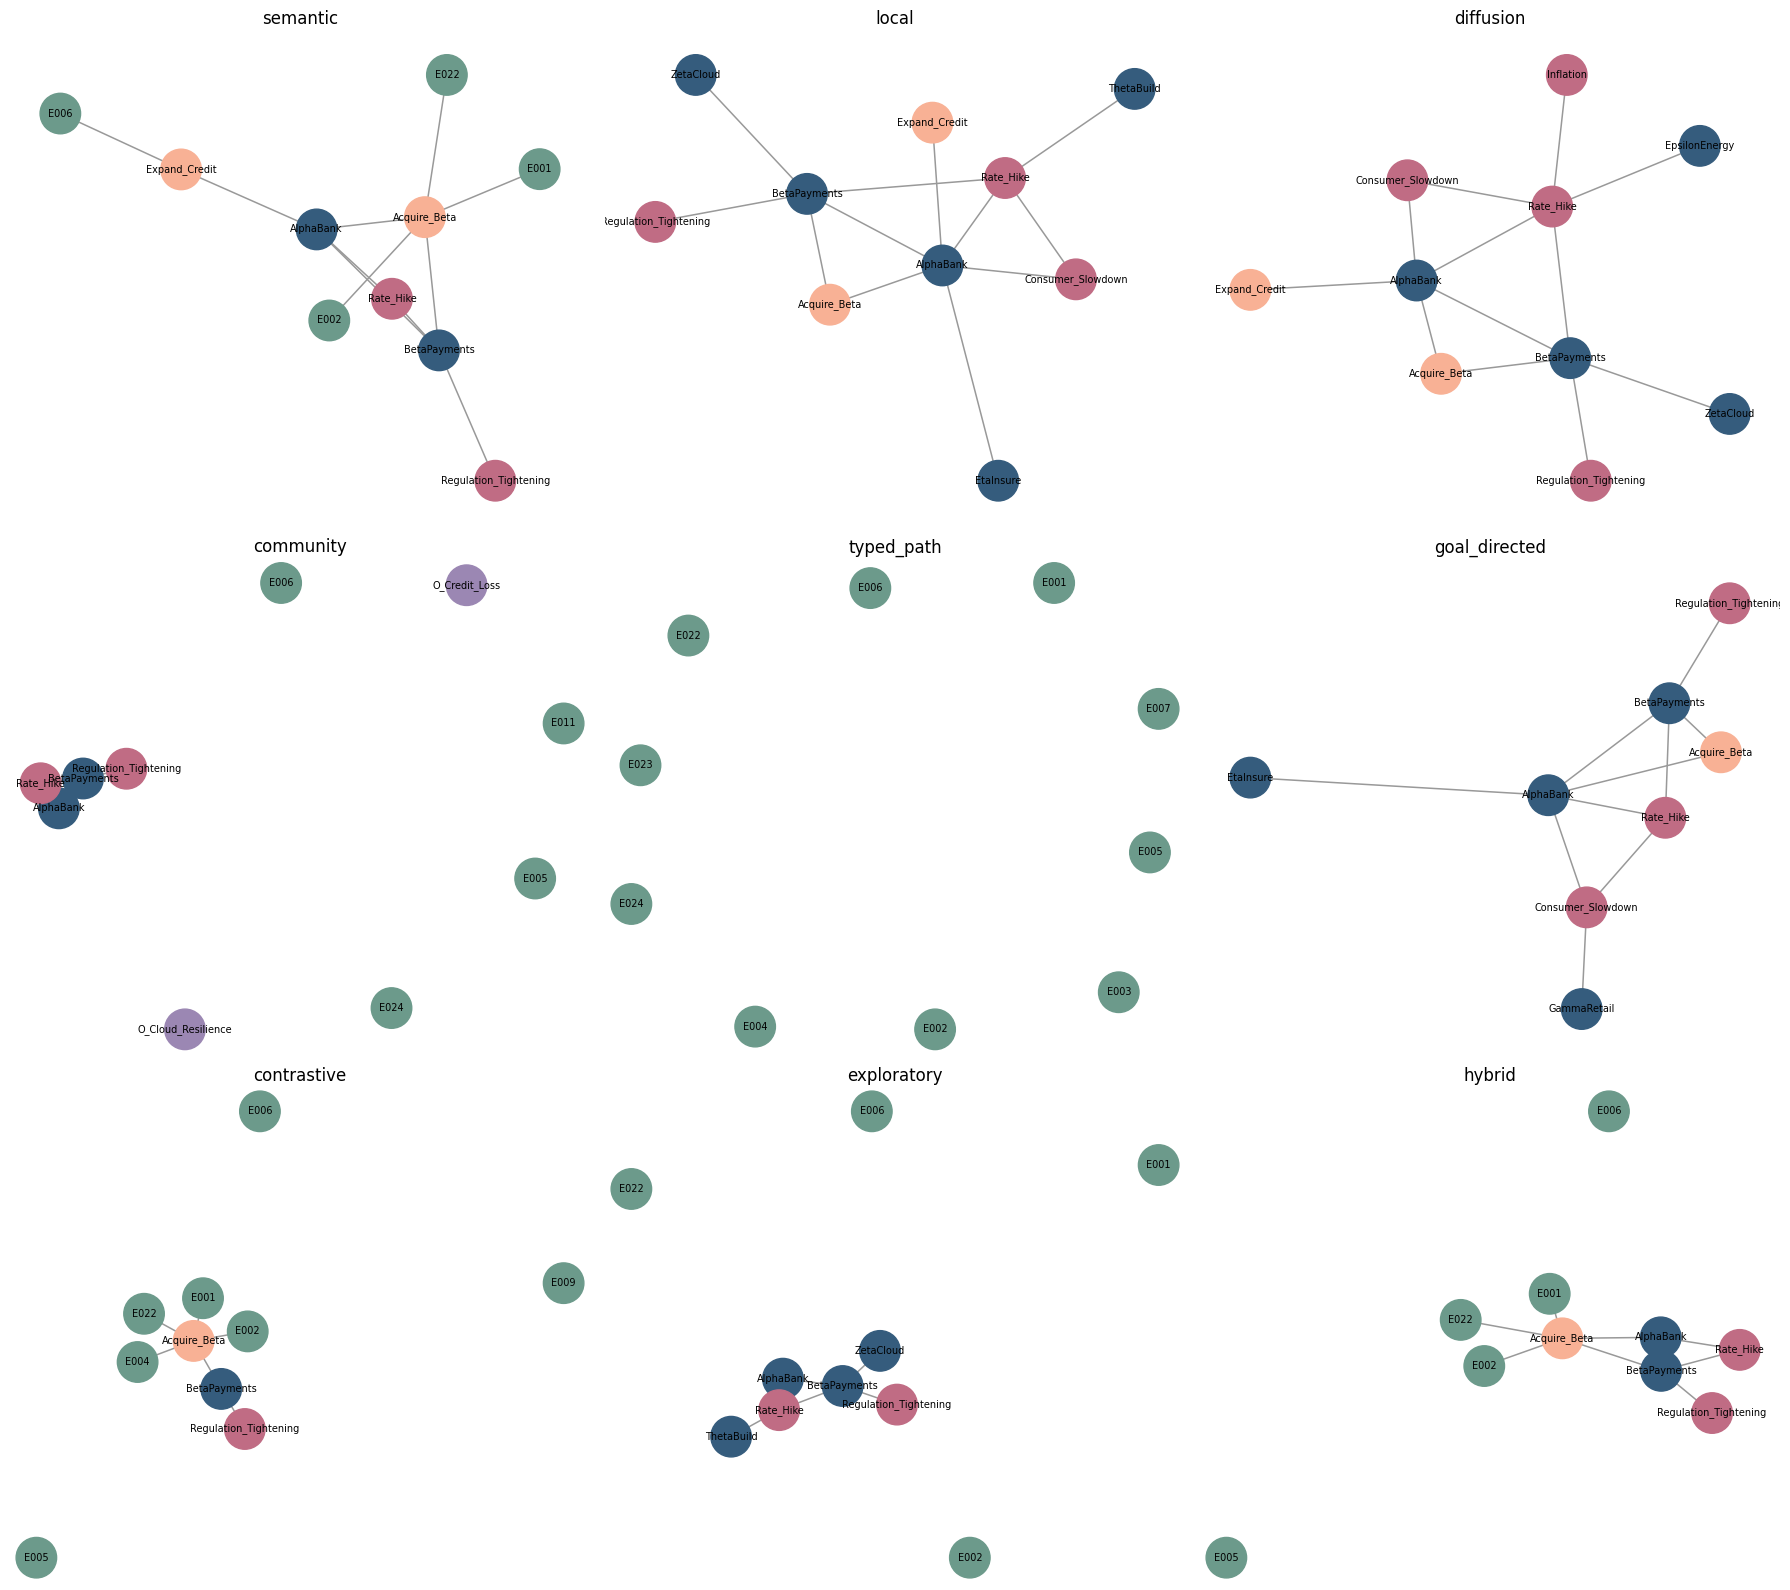

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for ax, trace in zip(axes.ravel(), traces):
    draw_context(g, trace, ax=ax, title=trace["policy"])
plt.tight_layout()
plt.savefig(LAB_ROOT / "NB13_policy_contexts.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Context-overlap matrix

A value of one means two policies exposed the answer interpreter to the same nodes. A value
near zero means the policies constructed substantially different cognitive contexts from the
same stored graph.

,semantic,local,diffusion,community,typed_path,goal_directed,contrastive,exploratory,hybrid
semantic,1.00,0.43,0.43,0.33,0.25,0.38,0.54,0.67,0.82
local,0.43,1.00,0.67,0.25,0.00,0.64,0.18,0.43,0.33
diffusion,0.43,0.67,1.00,0.25,0.00,0.50,0.18,0.33,0.33
community,0.33,0.25,0.25,1.00,0.18,0.29,0.25,0.33,0.43
typed_path,0.25,0.00,0.00,0.18,1.00,0.00,0.43,0.25,0.33
goal_directed,0.38,0.64,0.50,0.29,0.00,1.00,0.20,0.29,0.38
contrastive,0.54,0.18,0.18,0.25,0.43,0.20,1.00,0.43,0.67
exploratory,0.67,0.43,0.33,0.33,0.25,0.29,0.43,1.00,0.67
hybrid,0.82,0.33,0.33,0.43,0.33,0.38,0.67,0.67,1.00


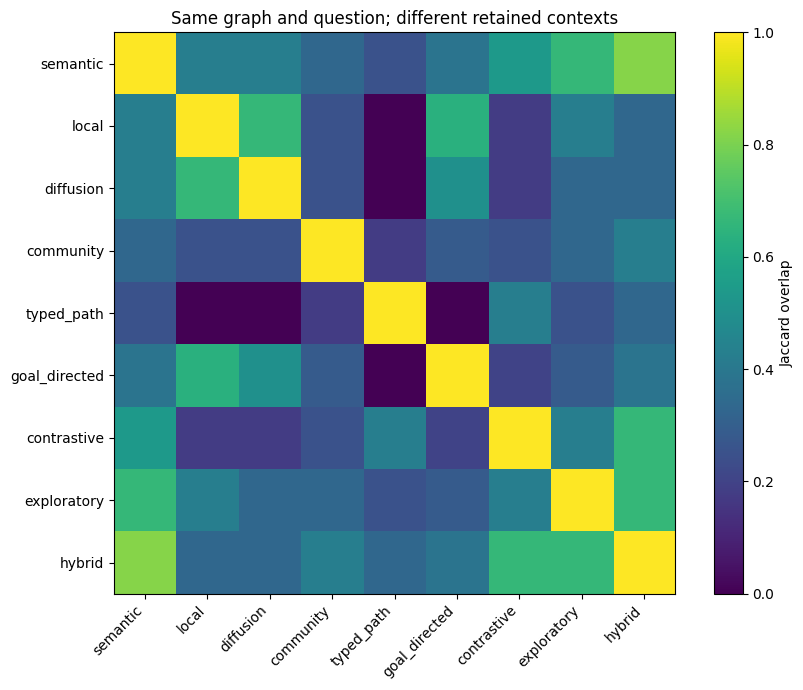

In [8]:
overlap = pd.DataFrame(index=POLICIES, columns=POLICIES, dtype=float)
trace_map = {t["policy"]: t for t in traces}
for p1 in POLICIES:
    for p2 in POLICIES:
        overlap.loc[p1, p2] = jaccard(trace_map[p1]["retained"], trace_map[p2]["retained"])
display(overlap.round(2))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(overlap.values.astype(float), vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(POLICIES)), POLICIES, rotation=45, ha="right")
ax.set_yticks(range(len(POLICIES)), POLICIES)
fig.colorbar(im, ax=ax, label="Jaccard overlap")
ax.set_title("Same graph and question; different retained contexts")
plt.tight_layout()
plt.savefig(LAB_ROOT / "NB13_context_overlap.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Export navigation records and run manifest

The record captures how context was constructed. The context hash makes later answer and
write-back objects cryptographically attributable to the exact retained node set.

In [9]:
save_jsonl(traces, LAB_ROOT / "NB13_navigation_records.jsonl")
trace_df.reset_index().to_csv(LAB_ROOT / "NB13_trace_summary.csv", index=False)
overlap.to_csv(LAB_ROOT / "NB13_context_overlap.csv")
outputs = [
    "baseline_graph.json", "queries.json", "policy_registry.json",
    "NB13_navigation_records.jsonl", "NB13_trace_summary.csv",
    "NB13_context_overlap.csv", "NB13_policy_contexts.png",
    "NB13_context_overlap.png", "Obsidian_Baseline_Vault/",
]
run_manifest = manifest("NB13", "G0", "G0", outputs, {
    "policy_parameters": {"budget": budget, "max_depth": 4},
    "scientific_control": "Only navigation policy varies.",
})
save_json(run_manifest, LAB_ROOT / "NB13_manifest.json")
print("NB13 complete. Outputs:")
print("\n".join(f"  - {name}" for name in outputs))

NB13 complete. Outputs:
  - baseline_graph.json
  - queries.json
  - policy_registry.json
  - NB13_navigation_records.jsonl
  - NB13_trace_summary.csv
  - NB13_context_overlap.csv
  - NB13_policy_contexts.png
  - NB13_context_overlap.png
  - Obsidian_Baseline_Vault/


## Interpretation

The graph is invariant, but the cognitively active subgraph is not. NB13 establishes the
experimental apparatus; NB14 scales the comparison across the complete query battery and
estimates the static effect of policy choice on context and answer.